In [1]:
import os
os.chdir('../pycode/')

In [2]:
from ecqf_tools import *

In [3]:
import matplotlib as mpl
from matplotlib.patches import Polygon,RegularPolygon,Rectangle,Circle
import matplotlib.pyplot as plt
import numpy as np

# Visualizing the Category of Elliptic Curves

There are two entry points:
1. We can obtain information about a whole isogeny class using ECQFIsogenyClass.
There are two types of things one can obtain here:
* A dataframe that displays a summary of the key elements in the bijection.
* Information about isogeny graphs of degree $\ell$, where $\ell$ is a prime. Note - this has not been implemented yet.
2. We can obtain information about a single elliptic curve. This can be done using ec_look_up.

Starting from one of these entry points, we can pass to the other:
* Given an isogeny class, we can choose a row and focus on a single element.
* ec_look_up gives us the trace of Frobenius, so we can construct the corresponding isogeny class.
Both classes rely on the same precomputed data.

## Isogeny Class Data

### Getting Started

An isogeny class is described by specifying a pair $(a,p)$, where:
* $p$ is prime
* $a^2 < 4p$

We're going to use precomputed data, so the first step is making sure the pair (a,p) appears in our precomputed data. This can be checked using the function 'ap_in_pc_data' below.

In [4]:
def ap_in_pc_data(ap:tuple[int,int])->bool:
    if ap[0]==0:
        return ap[1] in get_ssps_pc()
    else:
        return ap in get_aps_pc()

In [5]:
ap_in_pc_data((0,307)),ap_in_pc_data((0,1021))

(False, True)

In [6]:
ap_in_pc_data((12,1021))

True

## Bijection Data with ECQFIsogenyClass

If $(a,p)$ has a precomputed (EC->Lattice) bijection, this bijection can be loaded/cleaned/etc using ECQFIsogenyClass. Upon being called with a pair $a,p$, ECQFIsogenyClass does the following:
1. It checks that $a,p$ satisfy basic conditions ($a^2<4p$).
2. It checks whether $a,p$ appears in the precomputed data.
3. If the pair is in the precomputed data, it loads the data,
and stores the results of some computations that will be required frequently.

In [28]:
isoclass_ord = ECQFIsogenyClass(22,1021)
isoclass_ss = ECQFIsogenyClass(0,71)


### Dataframe

 A summary of all available data can be obtained in the form of a pandas data_frame:

In [8]:
isoclass_ord.ecqf_df().head()

,ec_invs,j_inv,EC_coefs,qf_coefs,endo_disc,endo_cond,endo_cocond,frobmat,tau_s,tau_xy
0,15,15,"(1019, 484)","(1, 0, 900)",-3600,30,1,"((11, -900), (1, 11))",15 √-4,"(-0.0, 30.0)"
1,399,399,"(380, 500)","(13, -12, 72)",-3600,30,1,"((5, -72), (13, 17))",(6+15 √-4)/13,"(0.462, 2.308)"
2,122,122,"(721, 415)","(25, 0, 36)",-3600,30,1,"((11, -36), (25, 11))",3 √-4/5,"(-0.0, 1.2)"
3,135,135,"(914, 718)","(13, 12, 72)",-3600,30,1,"((17, -72), (13, 5))",(-6+15 √-4)/13,"(-0.462, 2.308)"
4,217,217,"(438, 140)","(17, 2, 53)",-3600,30,1,"((12, -53), (17, 10))",(-1+15 √-4)/17,"(-0.059, 1.765)"


In [9]:
isoclass_ss.ecqf_df().head()

,ec_invs,j_inv,EC_coefs,qf_coefs,endo_disc,endo_cond,endo_cocond,frobmat,tau_s,tau_xy
0,"(24, 1)",24,"(1, 0)","(1, 0, 71)",-284,2,1,"((0, -71), (1, 0))",√-71,"(-0.0, 8.426)"
1,"(66, -1)",66,"(62, 39)","(3, 2, 24)",-284,2,1,"((1, -24), (3, -1))",(-1+ √-71)/3,"(-0.333, 2.809)"
2,"(41, 1)",41,"(39, 16)","(8, -2, 9)",-284,2,1,"((-1, -9), (8, 1))",(1+ √-71)/8,"(0.125, 1.053)"
3,"(0, 1)",0,"(0, 1)","(5, -4, 15)",-284,2,1,"((-2, -15), (5, 2))",(2+ √-71)/5,"(0.4, 1.685)"
4,"(0, -1)",0,"(0, 68)","(5, 4, 15)",-284,2,1,"((2, -15), (5, -2))",(-2+ √-71)/5,"(-0.4, 1.685)"


The column labels mean the following:
* 'ec_invs' contains a 'signature' associated to each row. For ordinary classes,
 (i.e. if $a\neq 0$), 'ec_invs' simply contains the j-invariant. For supersingular classes, this column contains pairs $(j,\pm 1)$, where $j$ is the $j$-invariant, and the sign $\pm 1$ is equal to 1 if the constant term is a square (or the constant term is 0 and the linear term is a square) and $-1$ otherwise. The signature (together with the trace of Frobenius, if the class is ordinary) completely determines the $\mathbb{F}_p$ isomorphism class of each row.
* 'j_inv': This column contains the $j$-invariants.
* 'EC_coefs': This column contains the coefficients $(c_4, c_6)$ of the short Weierstrass model $y^2 = x^3 + c_4 x + c_6$.
* 'qf_coefs': This column contains the coefficients $(a,b,c)$ of the minimal polynomial $ax^2+bxy+cy^2$ that determines the lattice class.
* 'endo_disc': This column contains the discriminant of the endomorphism ring of the object in that row.
* 'endo_cond': This contains the conductor of the endomorphism ring.
* 'endo_cocond': The integer in this column is the index $[\mathrm{End}(E):\mathbb{Z}[\phi_E]]$.
* 'frobmat': This column contains the matrices that represent the action of the lift of Frobenius on the lattice with respect to the ordered basis $1,\tau$.
* 'tau_s': This is a string that represents $\tau$
* 'tau_xy': These are the $x,y$ coordinates of $\tau$.


#### Pictures
We can make a visual summary of the lattices in a given isogeny class.
Each lattice class can be encoded into a point in the standard fundamental domain of the upper half plane mod the modular group.
We can make a picture that displays all of these points - it serves as a visual summary of the data in this class.

In [33]:
def uhmodgam_fd_plot(height):
    fig, ax = plt.subplots()
    ax.add_patch(mpl.patches.Rectangle((-0.5,0),width=1,height=height,facecolor=[0.7,0.7,0.7,0.5]))
    ax.add_patch(mpl.patches.Circle((0,0),1,facecolor='white',edgecolor='black'))
    plt.xlim(-1,1)
    plt.ylim(0,height)
    plt.figure(figsize=(2,height))
    plt.gca().set_aspect('equal')
    return fig, ax
    
def qfs_uhfd_plot(qflist):
    taus = np.array([abc_to_tau(qf) for qf in qflist])
    ymx = max(taus[::,1])    
    fig, ax = plt.subplots()
    ax.add_patch(mpl.patches.Rectangle((-0.5,0),width=1,height=ymx+0.1,facecolor=[0.7,0.7,0.7,0.5]))
    ax.add_patch(mpl.patches.Circle((0,0),1,facecolor='white',edgecolor='black'))
    plt.xlim(-1.1,1.1)
    plt.ylim(0,ymx+0.1)
    plt.figure(figsize=(2.2,ymx+0.1))
    ax.scatter(x = taus[::,0],y=taus[::,1])
    return fig,ax

def qfs_uhfd_plot_w_highlights(qflist,qf0):
    tau0 = abc_to_tau(qf0)
    fig,ax = qfs_uhfd_plot(qflist)
    ax.scatter(x = [tau0[0]],y=[tau0[1]],color ='red')
    return fig, ax


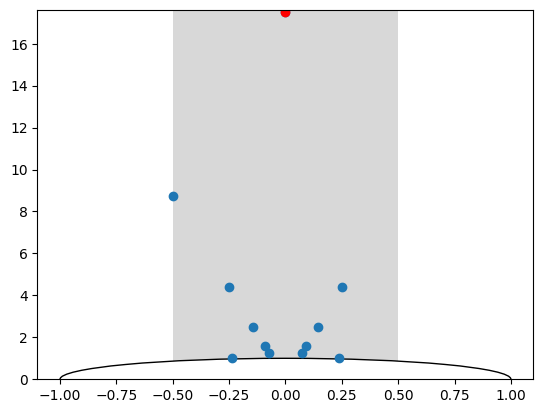

<Figure size 220x1762.14 with 0 Axes>

In [32]:
qfs_uhfd_plot_w_highlights(get_qfs_all(-4*307),(1,0,307))

### Isogeny Graph Data

This is not implemented yet, but the way it will work is - you will be able to call isoclass.isograph(l) and obtain data about isogenies of degree l between the objects in this class. I will add details later.

## Elliptic Curve Search

We can also take an elliptic curve as our input. The function 'ec_qf_lookup' plays the role of the ECQF class. The function takes as input a pair of integers $(f,g)$ and an integer $p$, 
where:
* $p>3$ is a prime number
* $f,g$ are the coefficients of a short Weierstrass equation:
$$ y^2 = x^3 + f x + g \pmod p$$

The function does the follwoing:
* It checks that the coefficients define a smooth curve.
* It computes the trace of Frobenius by doing a point count. 
* It checks whether the pair $(a,p)$ (technically, $(|a|,p)$) is in the precomputed data.

The function returns a dictionary with the data it computed/found. If precomputed bijections were computed, the dictionary contains the data normally found in the corresponding row of the dataframe.

### EC Look Up Legend

The keys mean the following:

* 'ap' is the pair $(a,p)$ containing the trace of Frobenius and characteristic of the field. These are also the coefficients of the characteristic polynomial.
* 'ec_eq' contains a string with the elliptic curve equation
*'j' is the $j$-invariant
* 's' is the 'signature' : equal to 1 if g is a nonzero square, -1 if g is nonsquare, 1 if g is zero and f is a square and -1 otherwise 
* 'frob_tr' is the trace of frobenius
* 'frob_disc' is the discriminant of the characteristic polynomial (a*a-4*p)
* 'endo_fun_disc' is the discriminant of the ring of integers of the endomorphism ring
* 'has_pcqf' is a boolean that is True if we can find a quadratic form associated to E in the precomputed data

When 'has_pcqf' is True, i.e. if we can find the isomorphism class of $E$ in the precomputed data, the dictionary has the following additional keys:
* 'qf' returns the triple of coefficients $(a,b,c)$ in the associated quadratic form:
 $$q(x,y)=ax^2+bxy+cy^2$$
 that determines the lattice class.
* 'frob_mat' is a MatrixElement that represents the action of Frobenius on the associated lattice relative to the basis $1,\tau$ of the associated lattice.
* 'tau_str' returns $\tau$ as a string
* 'tau_xy' returns the real and imaginary part of $\tau$.

In [12]:
ec_45_data = ec_look_up((3,0),5)
ec_45_data

{'ap': (-4, 5),
 'ec_eq': 'y^2 = x^3 + 3 x mod 5',
 'coefs': (3, 0),
 'j': 3,
 's': -1,
 'frob_tr': -4,
 'frob_disc': -4,
 'frob_cond': 1,
 'endo_fun_disc': -4,
 'has_pcqf': True,
 'qf': (1, 0, 1),
 'FrobMat':   -2    1
   -1   -2,
 'tau_str': ' √-1',
 'tau_xy': (np.float64(-0.0), np.float64(1.0))}

### Pictures

There are two types of pictures we will be making from the picture data.

* 'Classical' pictures, set in $\mathbb{F}_p^2$. Each curve has only one picture of this form.
* Lattice pictures, 'set' in a fundamental domain of $\mathbb{C}/\Lambda$. We can make pictures of the points defined over $\mathbb{F}_{p^n}$ for any $n$, so there are infinitely many pictures of this form parametrized by positive integers $n$.

#### Classical Pictures

We will use the integers between $\pm\frac{p}{2}$ as our fundamental domain for $\mathbb{Z}\pmod p$.

In [13]:
def fp_to_sym_fd(x:int,p:int)->int:
    xr = x %p
    if 2*xr < p:
        return xr
    else:
        return xr-p

def ec_eq_str(fg:tuple[int,int],p:int):
    eqs = 'y^2 = x^3'
    f,g = fg
    if f!= 0:
        if f>0:
            if f == 1:
                eqs+= ' + x'
            else:
                eqs+=f' + {f} x'
        else:
            f = -f
            if f == 1:
                eqs+= ' - x'
            else:
                eqs+=f' - {f} x'
    if g != 0:
        if g>0:
            eqs+=f' + {g}'
        else:
            g = -g
            eqs+=f' - {g}'
    return eqs+(f' mod {p}')
    
def ecfp_aff_pts(fg:tuple[int,int],p:int)->list[tuple[int,int]]:
    square_root_dic = {y2:[] for y2 in range(p)}
    for x in range(p):
        square_root_dic[pow(x,2,p)].append(x)
    pts = []
    f,g = fg
    for x in range(p):
        x = fp_to_sym_fd(x,p)
        y2 = (pow(x,3)+f*x+g)%p
        pts+=[(x,fp_to_sym_fd(y,p)) for y in square_root_dic[y2]]
    return pts    

def ecfp_classic_plot(ecdata:dict):
    fg = ecdata['coefs']
    p = ecdata['ap'][1]
    xys = ecfp_aff_pts(fg,p)
    xs = [xy[0] for xy in xys]
    ys = [xy[1] for xy in xys]
    ambientxys = [(x,y) for x in range(-(p//2),(p//2)+1) for y in range(-(p//2),(p//2)+1)]
    ambient_xs = [xy[0] for xy in ambientxys]
    ambient_ys = [xy[1] for xy in ambientxys]
    fig,ax = plt.subplots()
    plt.scatter(x = ambient_xs, y = ambient_ys, color = 'gray', alpha =0.3 )
    plt.scatter(x=xs,y=ys,color='purple')
    plt.scatter(x = [(p+1)//2],y=[(p+1)//2],color ='olive')
    ax.set_xticks([x for x in range(-(p//2),(p+1)//2)])
    ax.set_yticks([y for y in range(-(p//2),(p+1)//2)])
    plt.xlim((-(p+3)//2,(p+3)//2))
    plt.ylim((-(p+3)//2,(p+3)//2))
    plt.gca().set_aspect('equal')
    plt.box(False)
    plt.title(ecdata['ec_eq']) 


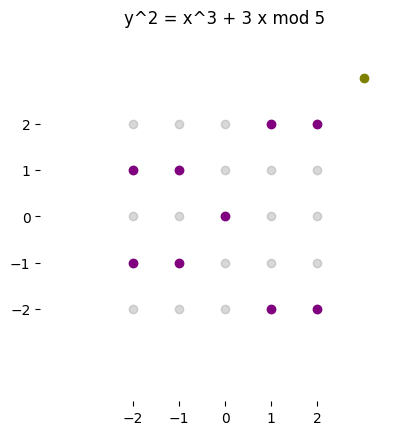

In [14]:
ecfp_classic_plot(ec_45_data)

#### Lattice pictures

We can also obtain lattice pictures directly from the data we looked up as follows:

In [21]:
# Obtain points on the lattice from the output of ec_look_up
def ecqf_mw_gens(ecdata:dict,k:int)->dict:
    return frob_to_mw_gens(ecdata['FrobMat'],k)

def ecqf_mw_arr(ecdata:dict,k:int)->np.array:
    mw_gens = ecqf_mw_gens(ecdata,k)
    qf = ecdata['qf']
    return mw_arr_from_gens(qf,mw_gens)



In [26]:
def qf_parallelogram_plot(qf:tuple[int,int,int]):
    verts = qf_parallelogram_verts(qf)
    xs = [v[0] for v in verts]
    xl, xr = min(xs),max(xs)
    ys = [v[1] for v in verts]
    ym = max(ys)
    fundom = Polygon(verts)
    fig, ax = plt.subplots()
    plt.xlim(xl-0.1,xr+0.1)
    plt.ylim(-0.1,ym+0.1)
    ax.add_patch(fundom)
    plt.gca().set_aspect('equal')
    return fig, ax

def qf_parallelogram_verts(qf):
    tau_arr = abc_to_tau(qf)
    one_arr = np.array([1,0])
    return [0*one_arr,one_arr,one_arr+tau_arr,tau_arr]

def qf_parallelogram_plot(qf:tuple[int,int,int]):
    verts = qf_parallelogram_verts(qf)
    xs = [v[0] for v in verts]
    xl, xr = min(xs),max(xs)
    ys = [v[1] for v in verts]
    ym = max(ys)
    fundom = Polygon(verts)
    fig, ax = plt.subplots()
    plt.xlim(xl-0.1,xr+0.1)
    plt.ylim(-0.1,ym+0.1)
    ax.add_patch(fundom)
    plt.gca().set_aspect('equal')
    return fig, ax

def ecqf_mw_lattice_plot(ecdata:dict,k:int):
    qf = ecdata['qf']
    pts = ecqf_mw_arr(ecdata,k)
    verts = qf_parallelogram_verts(qf)
    xs = [v[0] for v in verts]
    xl, xr = min(xs),max(xs)
    ys = [v[1] for v in verts]
    ym = max(ys)
    fundom = Polygon(verts,facecolor=[0.7,0.7,0.7,0.3])
    fig, ax = plt.subplots()
    plt.xlim(xl-0.1,xr+0.1)
    plt.ylim(-0.1,ym+0.1)
    ax.add_patch(fundom)
    ax.scatter(x = pts[::,0],y=pts[::,1],color='purple')
    ax.scatter(x = [0],y=[0],color='olive')
    plt.gca().set_aspect('equal')
    plt.box(False)
    return fig, ax

(<Figure size 640x480 with 1 Axes>, <Axes: >)

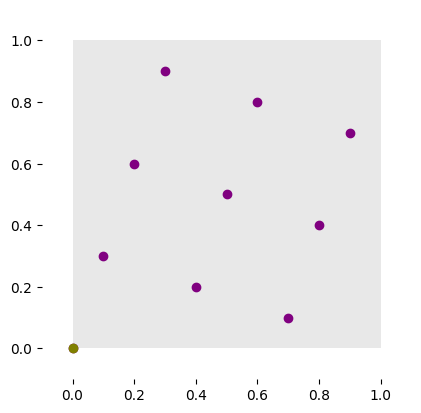

In [27]:
ecqf_mw_lattice_plot(ec_45_data,1)